# 06 · SHAP-IQ pairwise interactions (full dataset)

The campaign recorded no interactions stage, so the order-2 k-SII interaction values were computed once with SHAP-IQ from the campaign's exact split and model, over all 35,125 records, and stored under this notebook's figure directory.  
With the model's parameters frozen its reasoning is identical on every split, so full-dataset attribution carries no leakage, this is the same policy as the SHAP drift analysis.  
This notebook loads the recorded store and reports the global ranking and the full pairwise interaction matrix.

### Setup

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from _shared import ONE_HALF_COL, SINGLE_COL, init_notebook, jload, run_dir

FIG_DIR, savefig = init_notebook("06_interactions")

campaign: dce-full-rffs-4backbones-xgb-analyses-v2-2026-08-11
figures -> /Users/berthier/Development/PhD/xopa/results/notebook-figures/06_interactions


## k-SII interaction values (order 2) over all records

The recorded store `ksii_values_full.npz` holds the per-record k-SII values of the campaign model, computed once with SHAP-IQ on the campaign's exact split (the compute budget and seed are read back from the store below).  
Every result in this notebook derives from it, and the ranked table is exported as `ksii_interaction_values.csv` for the SHAP dependence plots of [04_explainability.ipynb](04_explainability.ipynb).

In [2]:
rffs_dir = run_dir("xgboost", "rffs")
final_features = jload(rffs_dir / "rffs_summary.json")["final_features"]
identity = jload(rffs_dir / "dataset_identity.json")

store = np.load(FIG_DIR / "ksii_values_full.npz", allow_pickle=True)
values = store["values"]
ordered_keys = [tuple(k) for k in json.loads(str(store["keys_json"]))]
assert len(values) == identity["cleaned_shape"][0], "store does not cover the full dataset"
mean_abs = np.abs(values).mean(axis=0)
print(f"k-SII over {len(values):,} records, {len(ordered_keys)} interaction terms")
print(f"store provenance: budget={int(store['budget'])} model evaluations per record, seed={int(store['seed'])}")


def key_label(key: tuple[int, ...]) -> str:
    return " x ".join(final_features[i] for i in key)


records = [
    {"order": len(key), "label": key_label(key), "value": mean_abs[idx]}
    for idx, key in enumerate(ordered_keys)
    if len(key) in (1, 2)
]
scores = (
    pd.DataFrame(records)
    .set_index(["order", "label"])["value"]
    .sort_values(ascending=False)
)
top_pairs = scores.loc[2].sort_values(ascending=False)
print("top-3 pairwise interactions over the full dataset:")
print(top_pairs.head(3).round(4).to_string())
scores.rename("mean_abs_ksii").reset_index().to_csv(
    FIG_DIR / "ksii_interaction_values.csv", index=False
)

k-SII over 35,125 records, 211 interaction terms
store provenance: budget=1024 model evaluations per record, seed=42
top-3 pairwise interactions over the full dataset:
label
data_108 x data_151    0.0928
data_001 x data_106    0.0850
data_118 x data_108    0.0784


## Global ranking: main effects and pairwise interactions

saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/06_interactions/ksii_top15.pdf/.png


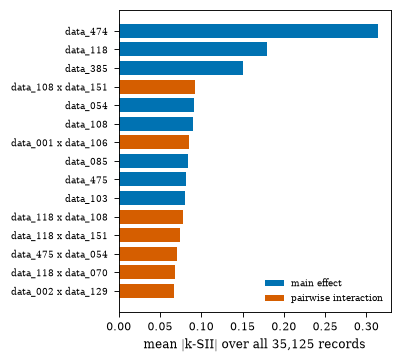

In [3]:
top = scores.head(15)
fig, ax = plt.subplots(figsize=(SINGLE_COL, 3.2))
colors = ["#0072B2" if order == 1 else "#D55E00" for order, _ in top.index]
ax.barh(range(len(top))[::-1], top.to_numpy(), color=colors, height=0.75)
ax.set_yticks(range(len(top))[::-1], [label for _, label in top.index], fontsize=6)
ax.set_xlabel(r"mean $|$k-SII$|$ over all 35,125 records")
handles = [
    plt.Rectangle((0, 0), 1, 1, fc="#0072B2", label="main effect"),
    plt.Rectangle((0, 0), 1, 1, fc="#D55E00", label="pairwise interaction"),
]
ax.legend(handles=handles, loc="lower right", fontsize=6)
savefig(fig, "ksii_top15")
plt.show()

## Full pairwise interaction matrix

Rows and columns are ordered by decreasing singleton (order-1) mean $|k$-SII$|$, so the matrix is sorted by its own diagonal and the strongest main effects and their couplings occupy the upper-left block.  
Outlined cells mark the three largest pairwise terms.

saved: /Users/berthier/Development/PhD/xopa/results/notebook-figures/06_interactions/ksii_pair_matrix.pdf/.png


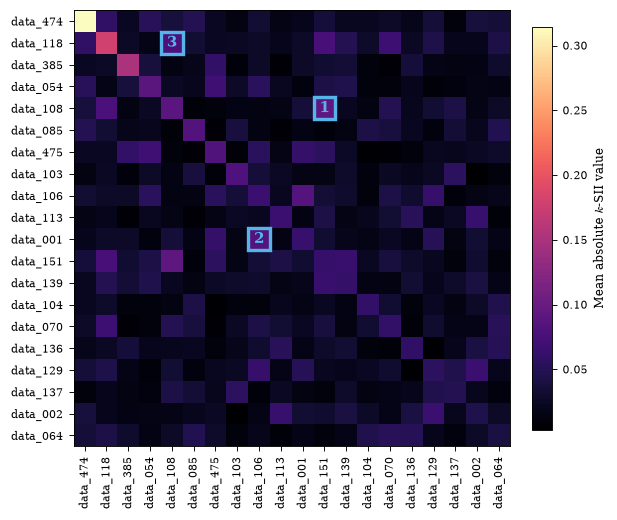

In [4]:
singleton_order = list(scores.loc[1].sort_values(ascending=False).index)
assert set(singleton_order) == set(final_features)

n = len(final_features)
pair_matrix = np.full((n, n), np.nan)
for idx, key in enumerate(ordered_keys):
    if len(key) == 2:
        i, j = key
        pair_matrix[i, j] = pair_matrix[j, i] = mean_abs[idx]
    elif len(key) == 1:
        pair_matrix[key[0], key[0]] = mean_abs[idx]
perm = [final_features.index(f) for f in singleton_order]
pair_matrix = pair_matrix[np.ix_(perm, perm)]

fig, ax = plt.subplots(figsize=(ONE_HALF_COL, 5.0))
im = ax.imshow(pair_matrix, cmap="magma")
ax.set_xticks(range(n), singleton_order, rotation=90, fontsize=7)
ax.set_yticks(range(n), singleton_order, fontsize=7)
fig.colorbar(im, ax=ax, label="Mean absolute $k$-SII value", shrink=0.8)
for rank, (label, value) in enumerate(top_pairs.head(3).items(), start=1):
    a, b = label.split(" x ")
    i, j = singleton_order.index(a), singleton_order.index(b)
    ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                               edgecolor="#56B4E9", lw=2.2))
    ax.text(
        j, i, str(rank), ha="center", va="center", color="#56B4E9",
        fontsize=9.5, fontweight="bold",
    )
savefig(fig, "ksii_pair_matrix")
plt.show()